## Entrenamiento de Deep Learning y Test de Robustez (Datos no Filtrados)

#  Montaje de Drive y entorno

In [1]:
!pip install mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 74.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [3]:
# --- 1. Montaje de Drive y entorno ---
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

PATH_REPO = '/content/drive/MyDrive/BCI-MENTORIA-UNC'
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

DIR_DATA = os.path.join(PATH_REPO, "data_procesada")

# --- 2. Carga del checkpoint de features (todos los sujetos, formato largo) ---
ruta_checkpoint = os.path.join(DIR_DATA, "features_largo_todos_sujetos.parquet")
df_check = pd.read_parquet(ruta_checkpoint)

print(f"Checkpoint de features: {df_check.shape}")
print("Sujetos:", df_check['subject_id'].nunique())

df_features_wide = df_check.pivot_table(
    index=['subject_id', 'trial_idx', 'label'],
    columns='feature_col',
    values='valor'
).reset_index()
df_features_wide['Clase_Nombre'] = df_features_wide['label'].map({0: 'Mano Izquierda', 1: 'Mano Derecha'})

print(f"df_features_wide: {df_features_wide.shape}")

# --- 3. Carga de la tabla de estabilidad y detalle por fold (Fase 2) ---
ruta_estabilidad = os.path.join(DIR_DATA, "tabla_estabilidad_features.csv")
tabla_estabilidad_pct = pd.read_csv(ruta_estabilidad, index_col=0)

ruta_seleccion_folds = os.path.join(DIR_DATA, "seleccion_features_por_fold.parquet")
df_seleccion_folds = pd.read_parquet(ruta_seleccion_folds)

print(f"\nTabla de estabilidad: {tabla_estabilidad_pct.shape}")
display(tabla_estabilidad_pct.head())

# --- 4. Carga de las features finales seleccionadas (umbral de consenso) ---
ruta_features_finales = os.path.join(DIR_DATA, "features_finales_seleccionadas.json")
with open(ruta_features_finales, 'r') as f:
    seleccion_guardada = json.load(f)

features_finales = seleccion_guardada['features']
UMBRAL_CONSENSO = seleccion_guardada['umbral_consenso']

print(f"\nFeatures finales cargadas ({len(features_finales)}, umbral={UMBRAL_CONSENSO}%):")
print(features_finales)

# --- 5. Dataset final listo para SVM / Random Forest / PCA+LDA ---
X_final = df_features_wide[features_finales]
y_final = df_features_wide['label']
groups_final = df_features_wide['subject_id']  # para mantener el mismo esquema de split por sujeto

print(f"\nX_final: {X_final.shape} | y_final: {y_final.shape} | Sujetos: {groups_final.nunique()}")

Mounted at /content/drive
Checkpoint de features: (1427400, 5)
Sujetos: 60
df_features_wide: (19032, 79)

Tabla de estabilidad: (72, 5)


,ANOVA,MI,RFE,Lasso,Consenso_Promedio_%
feature,,,,,
power_band_2_C3,100,80,60,100,85.0
AR_coef10_C4,100,20,100,100,80.0
potencia_total_C4,100,20,80,100,75.0
katz_fractal_C4,100,100,0,100,75.0
potencia_total_C3,80,40,80,100,75.0



Features finales cargadas (11, umbral=65%):
['power_band_2_C3', 'AR_coef10_C4', 'potencia_total_C4', 'katz_fractal_C4', 'potencia_total_C3', 'power_band_1_C3', 'entropia_perm_C3', 'AR_coef10_C3', 'power_band_2_C4', 'entropia_perm_C4', 'power_band_3_C4']

X_final: (19032, 11) | y_final: (19032,) | Sujetos: 60


In [4]:
# Llamamos a la base
import sys


sys.path.append(PATH_REPO)
os.chdir(PATH_REPO)

import mne
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset

mne.set_log_level('ERROR')

def binarize_y(y):
    unique_classes = np.unique(y)
    assert len(unique_classes) == 2, "y debe tener exactamente dos clases distintas"
    class_to_bin = {unique_classes[0]: 0, unique_classes[1]: 1}
    bin_to_class = {v: k for k, v in class_to_bin.items()}
    y_bin = np.vectorize(class_to_bin.get)(y)
    return y_bin, bin_to_class

DB_SELECCIONADA = "Dreyer2023A"
CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128
RANDOM_SEED = 45
K_FOLDS = 5

lista_sujetos = list(df_features_wide['subject_id'].unique())

dataset = PreprocessedDataset(
    db_name=DB_SELECCIONADA,
    sessions=SESSIONS,
    subjects=lista_sujetos,
    data_to_load=DATA_TO_LOAD,
    channels=CHANNELS,
)
print(f"Dataset instanciado. Sujetos disponibles: {len(lista_sujetos)}")

Dataset instanciado. Sujetos disponibles: 60


# 📌 Nota introductoria — Cómo usar esta notebook (Fase 3: Deep Learning)

Esta notebook contiene el entrenamiento y evaluación de EEGNet sobre los 60 sujetos, entrenado con max_epochs=500, patience=150 sobre señal cruda (sin filtrar), además de la comparación final contra SVM y CSP+LDA.

No es necesario reentrenar EEGNet desde cero. El resultado completo (60 sujetos, ~1 hora de cómputo) ya está guardado en disco. Alcanza con ejecutar la celda de carga de checkpoints al inicio de esta sección para recuperar:

Los resultados de EEGNet (df_eegnet_500_150), con accuracy promedio 0.6819.
Los resultados finales de SVM y CSP+LDA, necesarios para la comparación de los 3 métodos.
La comparación completa ya calculada (comparativa_SVM_CSP_EEGNet_500_150_final.csv), si ya existe.

Lo que sí hay que volver a ejecutar:

Las celdas de gráfico (plt.show()) que quieras visualizar — son rápidas, solo dibujan sobre datos ya cargados.
La Celda 13 (curvas de entrenamiento de los sujetos 43/45) — esta sí reentrena en vivo (no está guardada como checkpoint), y puede tardar unos minutos por sujeto dado max_epochs=500, patience=150.

En resumen:

Corré la celda de carga de checkpoints (una sola vez).
Corré las celdas de gráfico/comparación que necesites (rápido).
Si querés ver curvas de un sujeto nuevo (distinto a 43/45), corré la Celda 13 adaptada — ahí sí hay entrenamiento real de por medio.

⚠️ Cuidado con la Celda 12: borra el checkpoint principal de EEGNet (os.remove(ruta_checkpoint_500_150)). No la ejecutes salvo que quieras recalcular todo desde cero (~1 hora).

In [ ]:
# ============================================================================
# CARGA COMPLETA DE CHECKPOINTS — Fase 3 (Deep Learning / EEGNet)
# ============================================================================
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------------------------------------------------------
# ETAPA 0 — Entorno
# ----------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

PATH_REPO = '/content/drive/MyDrive/BCI-MENTORIA-UNC'
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
DIR_DATA = os.path.join(PATH_REPO, "data_procesada")

sys.path.append(PATH_REPO)
os.chdir(PATH_REPO)

import mne
mne.set_log_level('ERROR')
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset

def binarize_y(y):
    unique_classes = np.unique(y)
    class_to_bin = {unique_classes[0]: 0, unique_classes[1]: 1}
    bin_to_class = {v: k for k, v in class_to_bin.items()}
    return np.vectorize(class_to_bin.get)(y), bin_to_class

DB_SELECCIONADA = "Dreyer2023A"
CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128
RANDOM_SEED = 45
K_FOLDS = 5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ ETAPA 0 — Entorno listo. Device: {device}")

# ----------------------------------------------------------------------------
# ETAPA 1 — Features + dataset
# ----------------------------------------------------------------------------
try:
    df_check = pd.read_parquet(os.path.join(DIR_DATA, "features_largo_todos_sujetos.parquet"))
    df_features_wide = df_check.pivot_table(
        index=['subject_id', 'trial_idx', 'label'], columns='feature_col', values='valor'
    ).reset_index()
    df_features_wide['Clase_Nombre'] = df_features_wide['label'].map({0: 'Mano Izquierda', 1: 'Mano Derecha'})

    with open(os.path.join(DIR_DATA, "features_finales_seleccionadas.json"), 'r') as f:
        seleccion_guardada = json.load(f)
    features_finales = seleccion_guardada['features']

    lista_sujetos = list(df_features_wide['subject_id'].unique())

    dataset = PreprocessedDataset(db_name=DB_SELECCIONADA, sessions=SESSIONS,
                                    subjects=lista_sujetos, data_to_load=DATA_TO_LOAD,
                                    channels=CHANNELS)
    print(f"✅ ETAPA 1 — {len(lista_sujetos)} sujetos, dataset instanciado")
except Exception as e:
    print(f"⚠️ ETAPA 1 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 2 — Arquitectura EEGNet + funciones de entrenamiento/diagnóstico
# ----------------------------------------------------------------------------
class EEGNet(nn.Module):
    def __init__(self, n_channels=3, n_times=256, F1=8, D=2, F2=16, dropout_rate=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D), nn.ELU(),
            nn.AvgPool2d((1, 4)), nn.Dropout(dropout_rate)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1, 8)), nn.Dropout(dropout_rate)
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            out = self.block2(self.block1(dummy))
            flat_size = out.view(1, -1).shape[1]
        self.classifier = nn.Linear(flat_size, 1)

    def forward(self, x):
        x = self.block1(x); x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def entrenar_evaluar_eegnet_fold(X_train_raw, y_train, X_test_raw, y_test,
                                   n_channels, n_times, max_epochs=500, patience=150, seed=42):
    torch.manual_seed(seed)
    n_val = max(int(0.20 * len(X_train_raw)), 8)
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X_train_raw))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]
    X_tr, y_tr = X_train_raw[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train_raw[val_idx], y_train[val_idx]
    mean_tr = X_tr.mean(axis=(0, 2), keepdims=True)
    std_tr = X_tr.std(axis=(0, 2), keepdims=True)
    X_tr_n = (X_tr - mean_tr) / (std_tr + 1e-8)
    X_val_n = (X_val - mean_tr) / (std_tr + 1e-8)
    X_test_n = (X_test_raw - mean_tr) / (std_tr + 1e-8)

    def to_loader(X, y, bs, shuffle):
        Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=shuffle)

    train_loader = to_loader(X_tr_n, y_tr, 16, True)
    val_loader = to_loader(X_val_n, y_val, 32, False)
    model = EEGNet(n_channels=n_channels, n_times=n_times).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    best_val_loss, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    X_test_t = torch.tensor(X_test_n, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test_t)) > 0.5).float().cpu().numpy().flatten()
    return accuracy_score(y_test, preds), f1_score(y_test, preds), None


def entrenar_evaluar_eegnet_fold_diagnostico(X_train_raw, y_train, X_test_raw, y_test,
                                               n_channels, n_times, max_epochs=500, patience=150, seed=42):
    """Igual que entrenar_evaluar_eegnet_fold, pero devuelve también el history completo (para graficar)."""
    torch.manual_seed(seed)
    n_val = max(int(0.20 * len(X_train_raw)), 8)
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X_train_raw))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]
    X_tr, y_tr = X_train_raw[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train_raw[val_idx], y_train[val_idx]
    mean_tr = X_tr.mean(axis=(0, 2), keepdims=True)
    std_tr = X_tr.std(axis=(0, 2), keepdims=True)
    X_tr_n = (X_tr - mean_tr) / (std_tr + 1e-8)
    X_val_n = (X_val - mean_tr) / (std_tr + 1e-8)
    X_test_n = (X_test_raw - mean_tr) / (std_tr + 1e-8)

    def to_loader(X, y, bs, shuffle):
        Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=shuffle)

    train_loader = to_loader(X_tr_n, y_tr, 16, True)
    val_loader = to_loader(X_val_n, y_val, 32, False)
    model = EEGNet(n_channels=n_channels, n_times=n_times).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    best_val_loss, best_state, patience_counter = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(max_epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward(); optimizer.step()
            train_loss += loss.item() * xb.size(0)
            train_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                val_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    X_test_t = torch.tensor(X_test_n, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test_t)) > 0.5).float().cpu().numpy().flatten()
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    gap = history['train_acc'][-1] - acc
    return acc, f1, gap, history

print("✅ ETAPA 2 — EEGNet + funciones de entrenamiento/diagnóstico listas")

# ----------------------------------------------------------------------------
# ETAPA 3 — Resultados de EEGNet (60 sujetos, config 500/150)
# ----------------------------------------------------------------------------
try:
    df_eegnet_500_150 = pd.read_csv(os.path.join(PATH_REPO, "models", "EEGNet", "df_global_EEGNet_500_150.csv"))
    df_eegnet_todos = df_eegnet_500_150.copy()  # alias usado en la celda de comparación final
    print(f"✅ ETAPA 3 — EEGNet: {len(df_eegnet_500_150)} sujetos, "
          f"Accuracy promedio={df_eegnet_500_150['EEGNet_Accuracy'].mean():.4f}")
except Exception as e:
    print(f"⚠️ ETAPA 3 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 4 — SVM y CSP+LDA finales (necesarios para la comparación de 3 métodos)
# ----------------------------------------------------------------------------
try:
    df_final_svm = pd.read_csv(os.path.join(PATH_REPO, "models", "SVM", "df_final_SVM.csv"))
    df_final_csp = pd.read_csv(os.path.join(PATH_REPO, "models", "CSP_LDA",
                                             "df_final_CSP_LDA_con_banda_y_reg.csv"))
    assert df_final_csp['Version'].iloc[0] == "con_banda_y_reg"
    print(f"✅ ETAPA 4 — df_final_svm ({len(df_final_svm)}) / df_final_csp ({len(df_final_csp)})")
except Exception as e:
    print(f"⚠️ ETAPA 4 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 5 — Comparación final de los 3 métodos (si ya está guardada, se carga directo)
# ----------------------------------------------------------------------------
try:
    ruta_comp_final = os.path.join(PATH_REPO, "models", "comparaciones",
                                    "comparativa_SVM_CSP_EEGNet_500_150_final.csv")
    if os.path.exists(ruta_comp_final):
        df_comparacion_completa = pd.read_csv(ruta_comp_final)
        print(f"✅ ETAPA 5 — comparación final ya calculada, {len(df_comparacion_completa)} sujetos")
    else:
        print("⚠️ ETAPA 5 — todavía no existe el archivo final, hay que correr la Celda 21 (corregida)")
except Exception as e:
    print(f"⚠️ ETAPA 5 incompleta: {e}")

print("\n🏁 Carga de checkpoints (Fase 3) finalizada.")

# ----------------------------------------------------------------------------
# ETAPA 6 — Probabilidades por trial de EEGNet (para graficar ROC real)
# ----------------------------------------------------------------------------
try:
    DIR_EEGNET = os.path.join(PATH_REPO, "models", "EEGNet")
    DIR_PROBS = os.path.join(DIR_EEGNET, "probabilidades_por_sujeto")

    df_metricas_con_probs = pd.read_csv(os.path.join(DIR_EEGNET, "metricas_completas_EEGNet_con_probs.csv"))

    # Verificar cuántos archivos .npz de probabilidades existen realmente
    archivos_probs = [f for f in os.listdir(DIR_PROBS) if f.endswith('.npz')]

    print(f"✅ ETAPA 6 — df_metricas_con_probs: {len(df_metricas_con_probs)} sujetos | "
          f"Archivos .npz de probabilidades: {len(archivos_probs)}")
except Exception as e:
    print(f"⚠️ ETAPA 6 incompleta: {e}")
    print("   Si nunca corriste el reentrenamiento con guardado de probs, hay que lanzarlo primero.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ETAPA 0 — Entorno listo. Device: cpu
✅ ETAPA 1 — 60 sujetos, dataset instanciado
✅ ETAPA 2 — EEGNet + funciones de entrenamiento/diagnóstico listas
✅ ETAPA 3 — EEGNet: 60 sujetos, Accuracy promedio=0.6819
✅ ETAPA 4 — df_final_svm (60) / df_final_csp (60)
✅ ETAPA 5 — comparación final ya calculada, 60 sujetos

🏁 Carga de checkpoints (Fase 3) finalizada.


# Arquitectura de DL y entrenamiento
 ## (⚠️ Ejecutar solo si se quieren cambiar parametros)

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix)

# ----------------------------------------------------------------------------
# Función unificada:   + curva por época
# ----------------------------------------------------------------------------
def entrenar_evaluar_eegnet_completo(X_train_raw, y_train, X_test_raw, y_test,
                                       subject_id, fold_num,
                                       n_channels, n_times, max_epochs=100, patience=20, seed=42):
    torch.manual_seed(seed)
    n_val = max(int(0.20 * len(X_train_raw)), 8)
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X_train_raw))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    X_tr, y_tr = X_train_raw[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train_raw[val_idx], y_train[val_idx]

    mean_tr = X_tr.mean(axis=(0, 2), keepdims=True)
    std_tr = X_tr.std(axis=(0, 2), keepdims=True)
    X_tr_n = (X_tr - mean_tr) / (std_tr + 1e-8)
    X_val_n = (X_val - mean_tr) / (std_tr + 1e-8)
    X_test_n = (X_test_raw - mean_tr) / (std_tr + 1e-8)

    def to_loader(X, y, bs, shuffle):
        Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=shuffle)

    train_loader = to_loader(X_tr_n, y_tr, 16, True)
    val_loader = to_loader(X_val_n, y_val, 32, False)

    model = EEGNet(n_channels=n_channels, n_times=n_times).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

    best_val_loss, best_state, patience_counter = float('inf'), None, 0
    registro_curvas = []

    for epoch in range(max_epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward(); optimizer.step()
            train_loss += loss.item() * xb.size(0)
            train_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                val_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        registro_curvas.append({'subject': subject_id, 'subset': 'train', 'fold': fold_num,
                                 'epoch': epoch, 'accuracy': train_acc, 'loss': train_loss})
        registro_curvas.append({'subject': subject_id, 'subset': 'val', 'fold': fold_num,
                                 'epoch': epoch, 'accuracy': val_acc, 'loss': val_loss})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    X_test_t = torch.tensor(X_test_n, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        logits_test = model(X_test_t)
        y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
        test_loss = criterion(logits_test, y_test_t).item()
        probs = torch.sigmoid(logits_test).cpu().numpy().flatten()
    preds = (probs > 0.5).astype(int)

    registro_curvas.append({'subject': subject_id, 'subset': 'test', 'fold': fold_num,
                             'epoch': None, 'accuracy': (preds == y_test).mean(), 'loss': test_loss})

    return preds, probs, y_test, registro_curvas


# ----------------------------------------------------------------------------
# Loop principal: 60 sujetos, con checkpoint doble
# ----------------------------------------------------------------------------
DIR_EEGNET = os.path.join(PATH_REPO, "models", "EEGNet")
os.makedirs(DIR_EEGNET, exist_ok=True)

ruta_metricas_eegnet = os.path.join(DIR_EEGNET, "metricas_completas_EEGNet.csv")
ruta_curvas_eegnet = os.path.join(DIR_EEGNET, "curvas_entrenamiento_EEGNet.csv")

if os.path.exists(ruta_metricas_eegnet):
    df_metricas_eegnet = pd.read_csv(ruta_metricas_eegnet)
    sujetos_ya_procesados = set(df_metricas_eegnet['subject_id'].tolist())
    print(f"Checkpoint encontrado: {len(sujetos_ya_procesados)} sujetos ya procesados")
else:
    df_metricas_eegnet = pd.DataFrame()
    sujetos_ya_procesados = set()

if os.path.exists(ruta_curvas_eegnet):
    df_curvas_eegnet = pd.read_csv(ruta_curvas_eegnet)
else:
    df_curvas_eegnet = pd.DataFrame()

sujetos_pendientes = [s for s in lista_sujetos if s not in sujetos_ya_procesados]
print(f"Sujetos pendientes: {len(sujetos_pendientes)}")

inicio = time.time()

for sujeto_id in sujetos_pendientes:
    t0 = time.time()
    try:
        X_eeg_s, Y_labels_s, _ = dataset.flatten_pool_data(subject_ids=[sujeto_id])
        y_s, _ = binarize_y(Y_labels_s)

        cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

        y_test_total, preds_total, probs_total = [], [], []
        registros_sujeto = []

        for fold_i, (train_idx, test_idx) in enumerate(cv_estrategia.split(X_eeg_s, y_s)):
            preds, probs, y_test, registro_curvas = entrenar_evaluar_eegnet_completo(
                X_eeg_s[train_idx], y_s[train_idx],
                X_eeg_s[test_idx], y_s[test_idx],
                subject_id=sujeto_id, fold_num=fold_i + 1,
                n_channels=X_eeg_s.shape[1], n_times=X_eeg_s.shape[2],
                seed=RANDOM_SEED + fold_i
            )
            y_test_total.extend(y_test)
            preds_total.extend(preds)
            probs_total.extend(probs)
            registros_sujeto.extend(registro_curvas)

        y_test_total = np.array(y_test_total)
        preds_total = np.array(preds_total)
        probs_total = np.array(probs_total)

        try:
            auc = roc_auc_score(y_test_total, probs_total)
        except Exception:
            auc = np.nan
        tn, fp, fn, tp = confusion_matrix(y_test_total, preds_total, labels=[0, 1]).ravel()

        fila_metricas = {
            'subject_id': sujeto_id, 'modelo': 'EEGNet',
            'accuracy': (preds_total == y_test_total).mean(),
            'precision': precision_score(y_test_total, preds_total, zero_division=0),
            'recall': recall_score(y_test_total, preds_total, zero_division=0),
            'f1': f1_score(y_test_total, preds_total, zero_division=0),
            'auc_roc': auc, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        }

        df_metricas_eegnet = pd.concat([df_metricas_eegnet, pd.DataFrame([fila_metricas])], ignore_index=True)
        df_metricas_eegnet.to_csv(ruta_metricas_eegnet, index=False)

        df_curvas_eegnet = pd.concat([df_curvas_eegnet, pd.DataFrame(registros_sujeto)], ignore_index=True)
        df_curvas_eegnet.to_csv(ruta_curvas_eegnet, index=False)

        print(f"Sujeto {sujeto_id}: accuracy={fila_metricas['accuracy']:.4f}, auc={fila_metricas['auc_roc']:.4f} "
              f"({time.time()-t0:.0f}s) [{len(df_metricas_eegnet)}/{len(lista_sujetos)}]")

    except Exception as e:
        print(f" ❌ ERROR en sujeto {sujeto_id}: {e}")
        continue

print(f"\n⭐ Tiempo total: {(time.time()-inicio)/60:.1f} min")
print("\n=== Resumen métricas EEGNet ===")
print(df_metricas_eegnet[['accuracy','precision','recall','f1','auc_roc']].mean().round(4))

Checkpoint encontrado: 1 sujetos ya procesados
Sujetos pendientes: 59
Sujeto 2: accuracy=0.5563, auc=0.6057 (67s) [2/60]
Sujeto 3: accuracy=0.8594, auc=0.9427 (108s) [3/60]
Sujeto 4: accuracy=0.6937, auc=0.7449 (69s) [4/60]
Sujeto 5: accuracy=0.6031, auc=0.6807 (56s) [5/60]
Sujeto 6: accuracy=0.6188, auc=0.6925 (101s) [6/60]
Sujeto 7: accuracy=0.7937, auc=0.8762 (67s) [7/60]
Sujeto 8: accuracy=0.5719, auc=0.5896 (42s) [8/60]
Sujeto 9: accuracy=0.7281, auc=0.7738 (78s) [9/60]
Sujeto 10: accuracy=0.6094, auc=0.6767 (85s) [10/60]
Sujeto 11: accuracy=0.6687, auc=0.7508 (69s) [11/60]
Sujeto 12: accuracy=0.5219, auc=0.5423 (57s) [12/60]
Sujeto 13: accuracy=0.6844, auc=0.7220 (78s) [13/60]
Sujeto 14: accuracy=0.5563, auc=0.5999 (77s) [14/60]
Sujeto 15: accuracy=0.8313, auc=0.9208 (87s) [15/60]
Sujeto 16: accuracy=0.6250, auc=0.7012 (82s) [16/60]
Sujeto 17: accuracy=0.6406, auc=0.6861 (95s) [17/60]
Sujeto 18: accuracy=0.7625, auc=0.8635 (81s) [18/60]
Sujeto 19: accuracy=0.8688, auc=0.9360 (93s

Resultado interesante:
EEGNet, entrenado directamente sobre señal cruda sin ningún preprocesamiento manual, alcanzó un accuracy promedio de 0.6819 (± 0.0509) sobre los 60 sujetos, superando de forma clara al baseline CSP+LDA optimizado (0.63, banda Alfa+Beta con regularización) y también al SVM Lineal sobre features manuales (0.6229). Esto es notable considerando que la red partió de datos crudos (sin filtrado de banda, sin extracción de características neurofisiológicas), a diferencia de CSP+LDA, donde sí se apuntó explícitamente a analizar la banda Alfa-Beta (8-30 Hz) como paso de preprocesamiento.

Este resultado sugiere que la arquitectura convolucional de EEGNet logró aprender, por sí misma y a partir de los datos, una representación funcionalmente útil de la señal (posiblemente emulando de forma implícita el tipo de filtrado espacial y temporal que CSP y las features manuales requieren definir explícitamente), sin necesidad de que se le indicara en qué banda de frecuencia o qué transformación buscar.

Sin embargo, este desempeño superior viene acompañado de un Gap_overfitting considerablemente más alto (0.1786 en promedio, con casos de hasta 0.325) comparado con SVM (0.0553) y CSP+LDA (0.0370), lo que indica que la red, si bien alcanza mayor accuracy, generaliza de forma menos estable entre train y test —un patrón esperable dada la mayor capacidad del modelo frente al tamaño limitado del dataset por sujeto.

⚡ALERTA También se observa lo ya destacado anteriormente donde en N_trials hay un minimo de 240, cuando todos los sujetos suponen tener 320 trials; esto puede indicar que debe existir al menos UN sujeto que solo tiene 240 y que por consiguiente, no debe haber completado la sesión.

### ✅ Tabla estructurada: subject, subset, fold, epoch, accuracy, loss

In [ ]:
df_curvas_eegnet_reducido = pd.read_csv(
    os.path.join(PATH_REPO, "models", "EEGNet", "curvas_entrenamiento_EEGNet.csv")
)

df_metricas_eegnet_reducido = pd.read_csv(
    os.path.join(PATH_REPO, "models", "EEGNet", "metricas_completas_EEGNet.csv")
)

print(df_curvas_eegnet_reducido.columns.tolist())
print(f"Filas totales: {len(df_curvas_eegnet_reducido)}")
print(f"Sujetos únicos: {df_curvas_eegnet_reducido['subject'].nunique()}")
print(f"Subsets: {df_curvas_eegnet_reducido['subset'].unique()}")
display(df_curvas_eegnet_reducido.head(10))

['subject', 'subset', 'fold', 'epoch', 'accuracy', 'loss']
Filas totales: 36660
Sujetos únicos: 60
Subsets: ['train' 'val' 'test']


,subject,subset,fold,epoch,accuracy,loss
0,1,train,1,0.0,0.560976,0.689880
1,1,val,1,0.0,0.470588,0.694974
2,1,train,1,1.0,0.541463,0.689968
3,1,val,1,1.0,0.470588,0.689867
4,1,train,1,2.0,0.614634,0.670544
5,1,val,1,2.0,0.607843,0.683945
6,1,train,1,3.0,0.595122,0.684700
7,1,val,1,3.0,0.627451,0.676857
8,1,train,1,4.0,0.580488,0.669213
9,1,val,1,4.0,0.647059,0.673814


In [ ]:
# Ver el máximo de épocas alcanzadas (debería rondar 100, no 500)
print(df_curvas_eegnet_reducido['epoch'].max())

# Confirmar accuracy promedio (debería coincidir con lo que ya viste: ~0.657)
print(df_metricas_eegnet_reducido[['accuracy','precision','recall','f1','auc_roc']].mean().round(4))

484.0
accuracy     0.6570
precision    0.6581
recall       0.6679
f1           0.6616
auc_roc      0.7089
dtype: float64


### ✅ Curvas de entrenamiento graficables para cualquier sujeto/fold

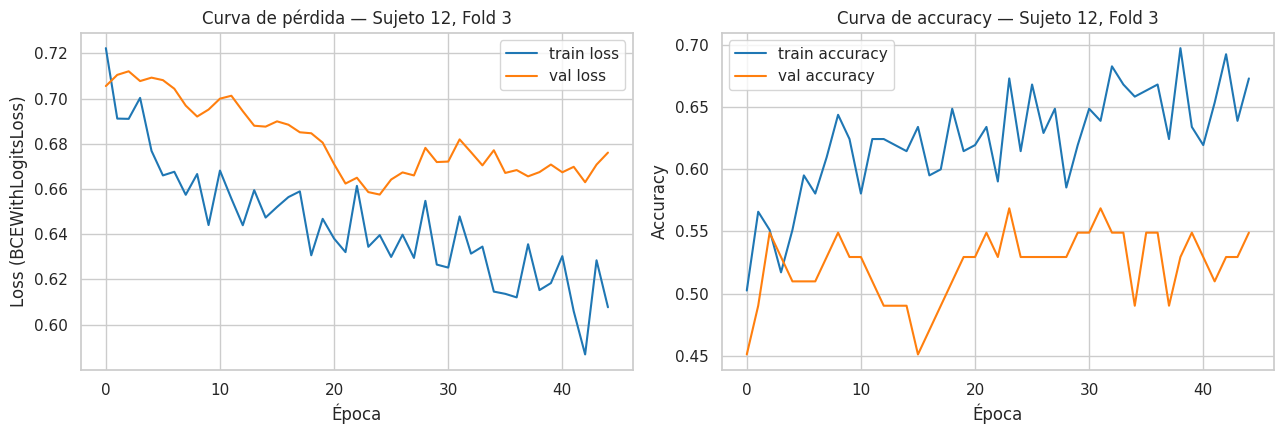

Test — Accuracy: 0.5781, Loss: 0.6772


In [ ]:
import matplotlib.pyplot as plt

def graficar_curvas_desde_tabla(df_curvas, subject_id, fold_num):
    """
    Reconstruye la curva de entrenamiento (Loss y Accuracy, train vs val)
    de cualquier sujeto y fold, directamente desde la tabla estructurada
    (subject, subset, fold, epoch, accuracy, loss) — sin reentrenar nada.
    """
    df_sujeto_fold = df_curvas[
        (df_curvas['subject'] == subject_id) &
        (df_curvas['fold'] == fold_num) &
        (df_curvas['subset'].isin(['train', 'val']))
    ]

    if df_sujeto_fold.empty:
        print(f"⚠️ No hay datos para Sujeto {subject_id}, Fold {fold_num}. "
              f"Sujetos disponibles: {sorted(df_curvas['subject'].unique())}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for subset, color in [('train', '#1f77b4'), ('val', '#ff7f0e')]:
        df_s = df_sujeto_fold[df_sujeto_fold['subset'] == subset]
        axes[0].plot(df_s['epoch'], df_s['loss'], label=f'{subset} loss', color=color)
        axes[1].plot(df_s['epoch'], df_s['accuracy'], label=f'{subset} accuracy', color=color)

    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss (BCEWithLogitsLoss)')
    axes[0].set_title(f'Curva de pérdida — Sujeto {subject_id}, Fold {fold_num}')
    axes[0].legend()

    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Curva de accuracy — Sujeto {subject_id}, Fold {fold_num}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Métricas finales de ese fold (test), si están disponibles
    fila_test = df_curvas[
        (df_curvas['subject'] == subject_id) &
        (df_curvas['fold'] == fold_num) &
        (df_curvas['subset'] == 'test')
    ]
    if not fila_test.empty:
        print(f"Test — Accuracy: {fila_test['accuracy'].values[0]:.4f}, "
              f"Loss: {fila_test['loss'].values[0]:.4f}")


# --- Ejemplo de uso: cualquier sujeto y fold, sin reentrenar ---
graficar_curvas_desde_tabla(df_curvas_eegnet_100_20, subject_id=12, fold_num=3) ##Aca voy cambiando

### ✅ Métricas obligatorias completas de EEGNet (Accuracy/Precision/Recall/F1/AUC-ROC/matriz de confusión)

In [ ]:
import pandas as pd
import os

# ============================================================
# Métricas obligatorias completas de EEGNet
# (Accuracy, Precision, Recall, F1, AUC-ROC, matriz de confusión)
# Ya calculadas y guardadas — no requiere reentrenar nada
# ============================================================

df_metricas_eegnet_reducido = pd.read_csv(
    os.path.join(PATH_REPO, "models", "EEGNet", "metricas_completas_EEGNet.csv")
)

print(f"Sujetos: {len(df_metricas_eegnet_reducido)}")
display(df_metricas_eegnet_reducido.head(10))

# --- Resumen promedio (60 sujetos) ---
print("\n=== Resumen promedio — EEGNet ===")
print(df_metricas_eegnet_reducido[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']].mean().round(4))

# --- Matriz de confusión agregada (suma de TN/FP/FN/TP de los 60 sujetos) ---
print("\n=== Matriz de confusión agregada (suma de los 60 sujetos) ===")
tn_total = df_metricas_eegnet_reducido['TN'].sum()
fp_total = df_metricas_eegnet_reducido['FP'].sum()
fn_total = df_metricas_eegnet_reducido['FN'].sum()
tp_total = df_metricas_eegnet_reducido['TP'].sum()

print(f"TN={tn_total}  FP={fp_total}")
print(f"FN={fn_total}  TP={tp_total}")

Sujetos: 60


,subject_id,modelo,accuracy,precision,recall,f1,auc_roc,TN,FP,FN,TP
0,1,EEGNet,0.684375,0.695364,0.65625,0.675241,0.745156,114,46,55,105
1,2,EEGNet,0.556250,0.560811,0.51875,0.538961,0.605664,95,65,77,83
2,3,EEGNet,0.859375,0.852761,0.86875,0.860681,0.942695,136,24,21,139
3,4,EEGNet,0.693750,0.689024,0.70625,0.697531,0.744922,109,51,47,113
4,5,EEGNet,0.603125,0.603774,0.60000,0.601881,0.680664,97,63,64,96
5,6,EEGNet,0.618750,0.618750,0.61875,0.618750,0.692539,99,61,61,99
6,7,EEGNet,0.793750,0.801282,0.78125,0.791139,0.876211,129,31,35,125
7,8,EEGNet,0.571875,0.572327,0.56875,0.570533,0.589648,92,68,69,91
8,9,EEGNet,0.728125,0.748299,0.68750,0.716612,0.773750,123,37,50,110
9,10,EEGNet,0.609375,0.624113,0.55000,0.584718,0.676680,107,53,72,88



=== Resumen promedio — EEGNet ===
accuracy     0.6570
precision    0.6581
recall       0.6679
f1           0.6616
auc_roc      0.7089
dtype: float64

=== Matriz de confusión agregada (suma de los 60 sujetos) ===
TN=6153  FP=3361
FN=3159  TP=6359


#### Visualización de la matriz de confusión agregada

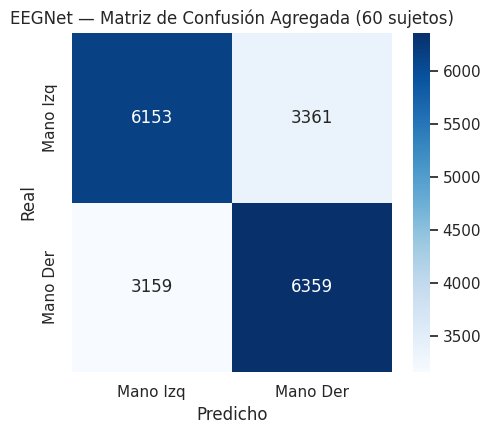

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

matriz = np.array([[tn_total, fp_total], [fn_total, tp_total]])

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mano Izq', 'Mano Der'],
            yticklabels=['Mano Izq', 'Mano Der'], ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('EEGNet — Matriz de Confusión Agregada (60 sujetos)')
plt.tight_layout()
plt.show()

### ✅ Métricas complementarias

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# Tabla resumen: Train Accuracy final, Val Accuracy final,
# Gap de overfitting y Test Accuracy — los 60 sujetos completos
# ============================================================

resumen_60_sujetos = []

for sujeto_id in df_curvas_eegnet_reducido['subject'].unique():
    df_suj = df_curvas_eegnet_reducido[df_curvas_eegnet_reducido['subject'] == sujeto_id]

    train_finales, val_finales, gaps_folds = [], [], []
    for fold_num in df_suj['fold'].unique():
        df_fold = df_suj[df_suj['fold'] == fold_num]
        train_final = df_fold[df_fold['subset'] == 'train']['accuracy'].iloc[-1]
        val_final = df_fold[df_fold['subset'] == 'val']['accuracy'].iloc[-1]
        train_finales.append(train_final)
        val_finales.append(val_final)
        gaps_folds.append(train_final - val_final)

    resumen_60_sujetos.append({
        'subject_id': sujeto_id,
        'Train_Accuracy_final': np.mean(train_finales),
        'Val_Accuracy_final': np.mean(val_finales),
        'Gap_overfitting': np.mean(gaps_folds)
    })

df_resumen_60 = pd.DataFrame(resumen_60_sujetos)

# --- Agregar el Test_Accuracy real (de las métricas obligatorias ya calculadas) ---
df_resumen_60 = df_resumen_60.merge(
    df_metricas_eegnet_reducido[['subject_id', 'accuracy']].rename(columns={'accuracy': 'Test_Accuracy'}),
    on='subject_id', how='left'
)

df_resumen_60 = df_resumen_60.sort_values('subject_id').reset_index(drop=True)

print(f"Sujetos: {len(df_resumen_60)}")
print(f"\nPromedios generales:")
print(df_resumen_60[['Train_Accuracy_final', 'Val_Accuracy_final', 'Gap_overfitting', 'Test_Accuracy']].mean().round(4))


# --- Guardar ---
ruta_resumen_60 = os.path.join(PATH_REPO, "models", "EEGNet", "resumen_train_val_test_60_sujetos.csv")
df_resumen_60.to_csv(ruta_resumen_60, index=False)
print(f"\n💾 Guardado en: {ruta_resumen_60}")

Sujetos: 60

Promedios generales:
Train_Accuracy_final    0.7637
Val_Accuracy_final      0.6687
Gap_overfitting         0.0950
Test_Accuracy           0.6570
dtype: float64

💾 Guardado en: /content/drive/MyDrive/BCI-MENTORIA-UNC/models/EEGNet/resumen_train_val_test_60_sujetos.csv


### 📊 Grafica de loss de un sujeto/fold de ejemplo

Sujeto 43: Accuracy=0.8906 | F1=0.8852 | Gap_overfitting=0.0021
Sujeto 45: Accuracy=0.6406 | F1=0.5965 | Gap_overfitting=0.1886


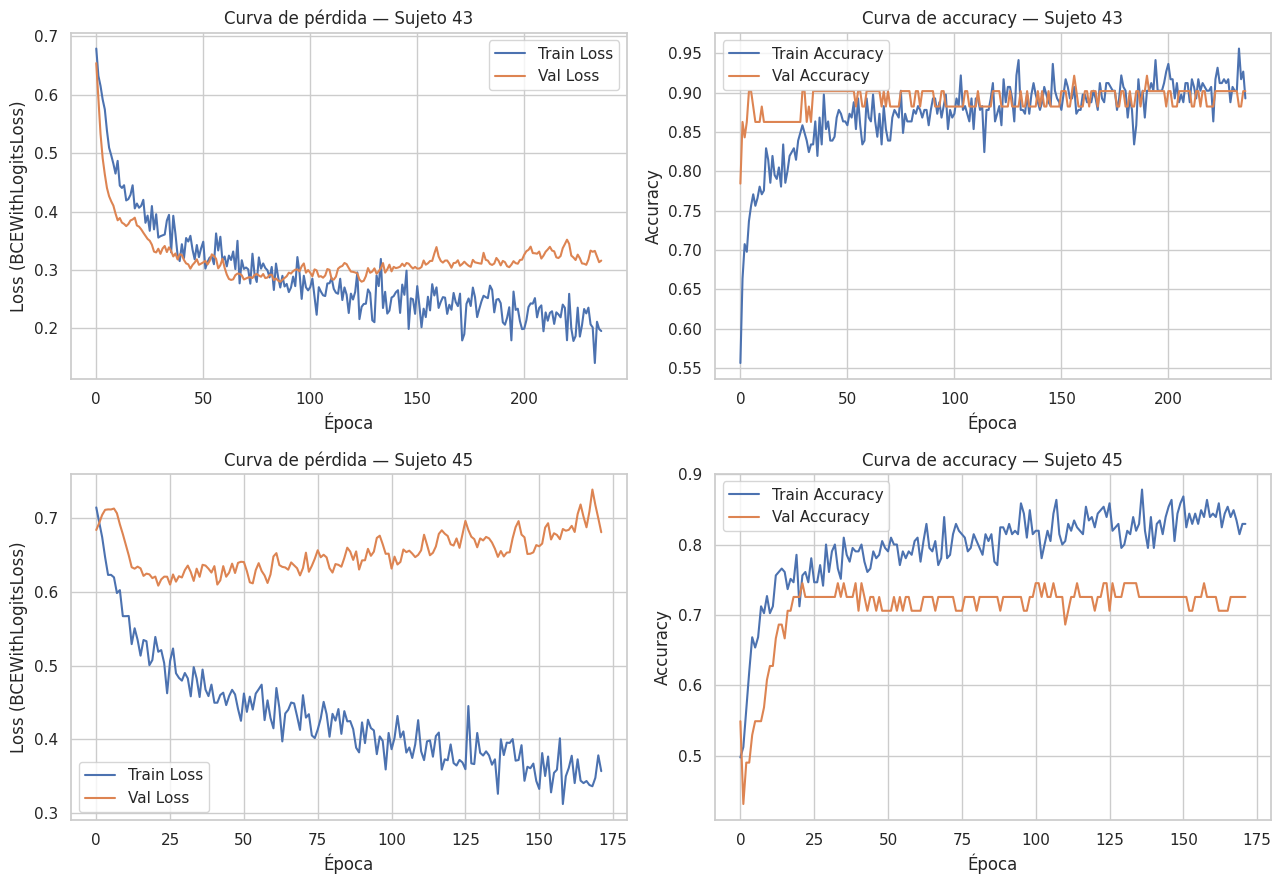

In [ ]:
import matplotlib.pyplot as plt

sujetos_diagnostico = [43, 45]
resultados_diagnostico = {}

for sujeto_id in sujetos_diagnostico:
    X_eeg_ej, Y_labels_ej, _ = dataset.flatten_pool_data(subject_ids=[sujeto_id])
    y_ej, _ = binarize_y(Y_labels_ej)

    cv_ejemplo = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    train_idx, test_idx = next(cv_ejemplo.split(X_eeg_ej, y_ej))  # primer fold, a modo de ejemplo

    acc, f1, gap, history = entrenar_evaluar_eegnet_fold_diagnostico(
        X_eeg_ej[train_idx], y_ej[train_idx],
        X_eeg_ej[test_idx], y_ej[test_idx],
        n_channels=X_eeg_ej.shape[1], n_times=X_eeg_ej.shape[2],
        seed=RANDOM_SEED
    )

    resultados_diagnostico[sujeto_id] = {'acc': acc, 'f1': f1, 'gap': gap, 'history': history}
    print(f"Sujeto {sujeto_id}: Accuracy={acc:.4f} | F1={f1:.4f} | Gap_overfitting={gap:.4f}")

# --- Graficar: 2 filas (una por sujeto) x 2 columnas (loss y accuracy) ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for i, sujeto_id in enumerate(sujetos_diagnostico):
    history = resultados_diagnostico[sujeto_id]['history']

    axes[i, 0].plot(history['train_loss'], label='Train Loss')
    axes[i, 0].plot(history['val_loss'], label='Val Loss')
    axes[i, 0].set_xlabel('Época')
    axes[i, 0].set_ylabel('Loss (BCEWithLogitsLoss)')
    axes[i, 0].set_title(f'Curva de pérdida — Sujeto {sujeto_id}')
    axes[i, 0].legend()

    axes[i, 1].plot(history['train_acc'], label='Train Accuracy')
    axes[i, 1].plot(history['val_acc'], label='Val Accuracy')
    axes[i, 1].set_xlabel('Época')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].set_title(f'Curva de accuracy — Sujeto {sujeto_id}')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

### Análisis de las curvas — Sujeto 43 vs Sujeto 45

#### Sujeto 43 — Aprendizaje saludable

Loss: Train y Val bajan juntas hasta ~época 150-200, y a partir de ahí se mantienen estables y cercanas (Train ~0.15, Val ~0.28). No hay separación creciente entre ambas curvas — la brecha se abre un poco al principio pero luego se mantiene constante, no se agranda con el tiempo.

Accuracy: Train y Val convergen ambas por encima de 0.90, con Val más ruidosa (oscila entre 0.85-0.95) pero sin tendencia a caer.

#### Sujeto 45 — Overfitting claro

Loss: Acá el patrón es opuesto. Train Loss baja consistentemente durante todo el entrenamiento (de 0.7 a ~ 0.35), mientras que Val Loss toca un mínimo muy temprano (~ época 20-30, alrededor de 0.60) y luego empieza a subir progresivamente, terminando incluso más alta que al principio (~0.70). Las curvas se separan cada vez más a medida que avanza el entrenamiento — la firma clásica de overfitting.

Accuracy: Train sigue subiendo sin parar hasta ~0.85-0.88, mientras que Val se estanca tempranamente en ~0.70 y se queda ahí, plana, sin acompañar la mejora del train.


#### - Conclusión:
En base a estas observaciones, se nota una clara diferencia en las tendencias que cada una de las gráficas sigue, a pesar de estar estos dos sujetos entrenados con exactamente la misma arquitectura, mismos hiperparámetros, mismo proceso.

El rango tan amplio del accuracy en EEGNet (0.46 a 0.90) es consistente con el fenómeno que ya se investigó: hay sujetos que modulan muy bien su actividad motora y otros que apenas superan el azar. Este es el mismo patrón de "BCI illiteracy" que se vió con CSP+LDA, ahora replicado también en el paradigma de Deep Learning.

La dificultad de algunos sujetos (como es lo que se observa en la gráfica del sujeto 45) no es específica del método clásico,  persiste incluso con un modelo que aprende sus propias representaciones, sugiriendo que la causa es más fisiológica (el sujeto realmente no modula bien) que una limitación de la técnica de extracción de features.

## Test estadístico pareado de los 3 métodos : (SVM_Linear) + (CSP+LDA) + (EEGNet)

#### 1. Recargar SVM + CSP desde la tabla ya guardada

In [ ]:
import os
import pandas as pd

ruta_comparacion_svm_csp = os.path.join(
    PATH_REPO, "models", "comparaciones", "comparativa_SVM_vs_CSPLDA_wide.csv"
)
df_comparacion_svm_csp = pd.read_csv(ruta_comparacion_svm_csp)

print(f"Filas: {len(df_comparacion_svm_csp)}")
print(df_comparacion_svm_csp.columns.tolist())
display(df_comparacion_svm_csp.head())

Filas: 60
['subject_id', 'SVM_CV_Accuracy', 'SVM_CV_Accuracy_std', 'SVM_CV_F1', 'SVM_Train_Accuracy', 'SVM_Gap_overfitting', 'SVM_Test_Accuracy_Final', 'CSP_CV_Accuracy', 'CSP_CV_Accuracy_std', 'CSP_CV_F1', 'CSP_Train_Accuracy', 'CSP_Gap_overfitting', 'CSP_Test_Accuracy_Final']


,subject_id,SVM_CV_Accuracy,SVM_CV_Accuracy_std,SVM_CV_F1,SVM_Train_Accuracy,SVM_Gap_overfitting,SVM_Test_Accuracy_Final,CSP_CV_Accuracy,CSP_CV_Accuracy_std,CSP_CV_F1,CSP_Train_Accuracy,CSP_Gap_overfitting,CSP_Test_Accuracy_Final
0,1,0.605656,0.052963,0.550171,0.651373,0.045716,0.593750,0.585671,0.107078,0.577740,0.634754,0.049083,0.593750
1,2,0.582202,0.048800,0.615471,0.624022,0.041820,0.656250,0.523379,0.027366,0.518417,0.552740,0.029362,0.421875
2,3,0.691327,0.065226,0.697678,0.707040,0.015712,0.515625,0.628959,0.075100,0.628686,0.681669,0.052710,0.750000
3,4,0.519231,0.043171,0.528864,0.609354,0.090124,0.546875,0.460860,0.032856,0.475972,0.549799,0.088939,0.500000
4,5,0.488612,0.071970,0.510066,0.572257,0.083645,0.500000,0.429789,0.036089,0.419895,0.541970,0.112182,0.515625


#### 2. Recargar tabla de EEGNet

In [ ]:
import os
import pandas as pd

ruta_eegnet_500_150 = os.path.join(PATH_REPO, "models", "EEGNet", "df_global_EEGNet_500_150.csv")
df_eegnet_todos = pd.read_csv(ruta_eegnet_500_150)

print(f"df_eegnet_todos recargado: {len(df_eegnet_todos)} filas")
print(f"Accuracy promedio: {df_eegnet_todos['EEGNet_Accuracy'].mean():.4f}")

df_eegnet_todos recargado: 60 filas
Accuracy promedio: 0.6819


#### 3. Comparación de los 3 métodos

In [ ]:
from scipy.stats import wilcoxon

# --- Cargar las 3 fuentes ---
df_metricas_ml = pd.read_csv(os.path.join(PATH_REPO, "models", "comparaciones", "metricas_completas_ML.csv"))
df_metricas_eegnet = pd.read_csv(os.path.join(PATH_REPO, "models", "EEGNet", "metricas_completas_EEGNet.csv"))

columnas_metricas = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']

df_svm = df_metricas_ml[df_metricas_ml['modelo'] == 'SVM'][['subject_id'] + columnas_metricas].rename(
    columns={c: f'SVM_{c}' for c in columnas_metricas})
df_csp = df_metricas_ml[df_metricas_ml['modelo'] == 'CSP_LDA'][['subject_id'] + columnas_metricas].rename(
    columns={c: f'CSP_{c}' for c in columnas_metricas})
df_eegnet = df_metricas_eegnet[['subject_id'] + columnas_metricas].rename(
    columns={c: f'EEGNet_{c}' for c in columnas_metricas})

df_comparacion_3_metodos = df_svm.merge(df_csp, on='subject_id', how='inner').merge(
    df_eegnet, on='subject_id', how='inner')

print(f"Sujetos comparados: {len(df_comparacion_3_metodos)}")

# --- Resumen promedio ---
resumen_3 = pd.DataFrame({
    'SVM': df_metricas_ml[df_metricas_ml['modelo']=='SVM'][columnas_metricas].mean(),
    'CSP+LDA': df_metricas_ml[df_metricas_ml['modelo']=='CSP_LDA'][columnas_metricas].mean(),
    'EEGNet': df_metricas_eegnet[columnas_metricas].mean()
}).round(4)
print("\n=== Resumen — 5 métricas, 3 métodos ===")
display(resumen_3)

# --- Wilcoxon pareado, por métrica, entre los 3 pares ---
print("\n=== Wilcoxon pareado ===")
resultados_wilcoxon_3 = []
pares = [('SVM','CSP'), ('SVM','EEGNet'), ('CSP','EEGNet')]

for metrica in columnas_metricas:
    for m1, m2 in pares:
        stat, p = wilcoxon(df_comparacion_3_metodos[f'{m1}_{metrica}'], df_comparacion_3_metodos[f'{m2}_{metrica}'])
        resultados_wilcoxon_3.append({'Métrica': metrica, 'Comparación': f'{m1} vs {m2}', 'p_value': round(p,4)})
        print(f"{metrica} — {m1} vs {m2}: p={p:.4f}")

df_wilcoxon_3_metodos = pd.DataFrame(resultados_wilcoxon_3)

Sujetos comparados: 60

=== Resumen — 5 métricas, 3 métodos ===


,SVM,CSP+LDA,EEGNet
accuracy,0.6229,0.6025,0.6570
precision,0.6288,0.6009,0.6581
recall,0.6174,0.6052,0.6679
f1,0.6164,0.5992,0.6616
auc_roc,0.6652,0.6323,0.7089



=== Wilcoxon pareado ===
accuracy — SVM vs CSP: p=0.0389
accuracy — SVM vs EEGNet: p=0.0492
accuracy — CSP vs EEGNet: p=0.0014
precision — SVM vs CSP: p=0.0216
precision — SVM vs EEGNet: p=0.1370
precision — CSP vs EEGNet: p=0.0010
recall — SVM vs CSP: p=0.8006
recall — SVM vs EEGNet: p=0.0193
recall — CSP vs EEGNet: p=0.0027
f1 — SVM vs CSP: p=0.3891
f1 — SVM vs EEGNet: p=0.0086
f1 — CSP vs EEGNet: p=0.0007
auc_roc — SVM vs CSP: p=0.0042
auc_roc — SVM vs EEGNet: p=0.0272
auc_roc — CSP vs EEGNet: p=0.0001


## Curvas ROC — SVM vs CSP+LDA vs EEGNet

✅ Setup completo


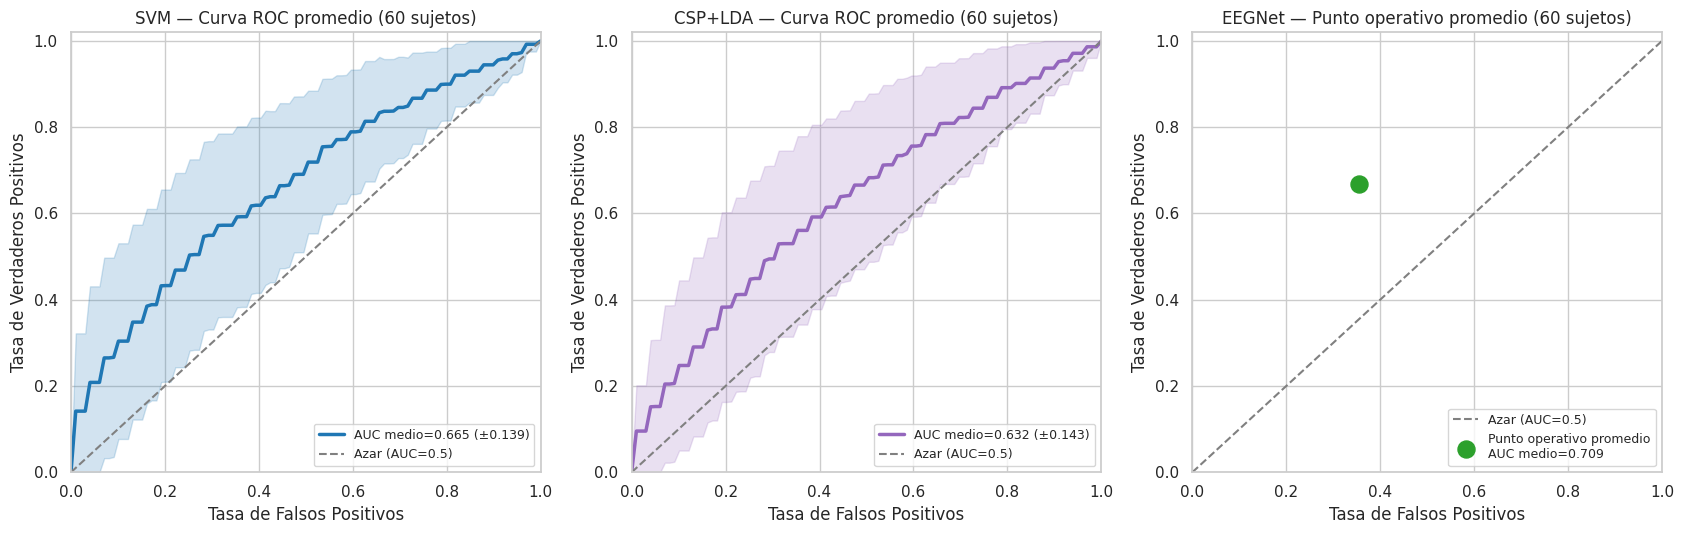

In [ ]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import mne

# --- Setup mínimo, por si faltan variables en esta sesión ---
PATH_REPO = '/content/drive/MyDrive/BCI-MENTORIA-UNC'
CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128
RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5

def binarizar_por_event_id(Y_labels, event_id):
    mapa = {event_id['left_hand']: 0, event_id['right_hand']: 1}
    return np.vectorize(mapa.get)(Y_labels)

def cargar_modelo(model_name, version_folder, subject_id):
    if version_folder:
        ruta = os.path.join(PATH_REPO, "models", model_name, version_folder,
                             f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
    else:
        ruta = os.path.join(PATH_REPO, "models", model_name,
                             f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
    with open(ruta, 'rb') as f:
        return pickle.load(f)

from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset
mne.set_log_level('ERROR')

df_check = pd.read_parquet(os.path.join(PATH_REPO, "data_procesada", "features_largo_todos_sujetos.parquet"))
df_features_wide = df_check.pivot_table(index=['subject_id','trial_idx','label'],
                                          columns='feature_col', values='valor').reset_index()

import json
with open(os.path.join(PATH_REPO, "data_procesada", "features_finales_seleccionadas.json")) as f:
    features_finales = json.load(f)['features']

lista_sujetos_dreyer = list(df_features_wide['subject_id'].unique())
dataset_dreyer = PreprocessedDataset(db_name="Dreyer2023A", sessions=SESSIONS,
                                       subjects=lista_sujetos_dreyer, data_to_load=DATA_TO_LOAD,
                                       channels=CHANNELS)

df_global_csp = pd.read_csv(os.path.join(PATH_REPO, "models", "CSP_LDA", "df_global_CSP_LDA_con_banda_y_reg.csv"))
import ast
mejores_params = ast.literal_eval(df_global_csp['Best_Params'].mode()[0])
BANDAS = {"alfa": (8,12), "beta": (13,30), "alfabeta": (8,30)}
L_FREQ_FINAL, H_FREQ_FINAL = BANDAS[mejores_params['banda']]

df_metricas_ml = pd.read_csv(os.path.join(PATH_REPO, "models", "comparaciones", "metricas_completas_ML.csv"))
df_metricas_eegnet = pd.read_csv(os.path.join(PATH_REPO, "models", "EEGNet", "metricas_completas_EEGNet.csv"))

print("✅ Setup completo")

# ============================================================
# Curvas ROC PROMEDIO (60 sujetos) — SVM, CSP+LDA, EEGNet
# ============================================================
mean_fpr = np.linspace(0, 1, 100)
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# --- SVM ---
tprs, aucs = [], []
for sujeto_id in lista_sujetos_dreyer:
    try:
        df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
        X = df_sujeto[features_finales].values
        y = df_sujeto['label'].values
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED)
        modelo = cargar_modelo('SVM', None, sujeto_id)
        y_score = modelo.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        tpr_i = np.interp(mean_fpr, fpr, tpr); tpr_i[0] = 0.0
        tprs.append(tpr_i); aucs.append(auc(fpr, tpr))
    except Exception:
        continue
tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0); mean_tpr[-1] = 1.0
std_tpr = tprs.std(axis=0)
axes[0].plot(mean_fpr, mean_tpr, color='#1f77b4', linewidth=2.5,
             label=f'AUC medio={np.mean(aucs):.3f} (±{np.std(aucs):.3f})')
axes[0].fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1),
                      color='#1f77b4', alpha=0.2)
axes[0].plot([0,1],[0,1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
axes[0].set_title('SVM — Curva ROC promedio (60 sujetos)')

# --- CSP+LDA ---
tprs, aucs = [], []
for sujeto_id in lista_sujetos_dreyer:
    try:
        X_eeg_raw, y_labels_raw, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_bin = binarizar_por_event_id(y_labels_raw, dataset_dreyer.event_id)
        X_filt = mne.filter.filter_data(X_eeg_raw.astype(np.float64), sfreq=SFREQ,
                                          l_freq=L_FREQ_FINAL, h_freq=H_FREQ_FINAL, method='iir', verbose=False)
        X_train, X_test, y_train, y_test = train_test_split(
            X_filt, y_labels_bin, test_size=SPLIT_TEST_SIZE, stratify=y_labels_bin, random_state=RANDOM_SEED)
        modelo = cargar_modelo('CSP_LDA', 'con_banda_y_reg', sujeto_id)
        y_score = modelo.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        tpr_i = np.interp(mean_fpr, fpr, tpr); tpr_i[0] = 0.0
        tprs.append(tpr_i); aucs.append(auc(fpr, tpr))
    except Exception:
        continue
tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0); mean_tpr[-1] = 1.0
std_tpr = tprs.std(axis=0)
axes[1].plot(mean_fpr, mean_tpr, color='#9467bd', linewidth=2.5,
             label=f'AUC medio={np.mean(aucs):.3f} (±{np.std(aucs):.3f})')
axes[1].fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1),
                      color='#9467bd', alpha=0.2)
axes[1].plot([0,1],[0,1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
axes[1].set_title('CSP+LDA — Curva ROC promedio (60 sujetos)')

# --- EEGNet: solo punto operativo promedio (no hay probs guardadas por trial) ---
fpr_prom = (df_metricas_eegnet['FP'] / (df_metricas_eegnet['FP'] + df_metricas_eegnet['TN'])).mean()
tpr_prom = (df_metricas_eegnet['TP'] / (df_metricas_eegnet['TP'] + df_metricas_eegnet['FN'])).mean()
auc_prom_eegnet = df_metricas_eegnet['auc_roc'].mean()
axes[2].plot([0,1],[0,1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
axes[2].scatter([fpr_prom], [tpr_prom], color='#2ca02c', s=150, zorder=5,
                label=f'Punto operativo promedio\nAUC medio={auc_prom_eegnet:.3f}')
axes[2].set_title('EEGNet — Punto operativo promedio (60 sujetos)')

for ax in axes:
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.show()

## Conclusión — Comparación ML clásico vs. Deep Learning

El análisis comparativo entre los tres enfoques evaluados sobre los 60 sujetos arrojó las siguientes medias de accuracy: SVM Lineal (features manuales) = 0.62, CSP+LDA (baseline de industria) = 0.60, y EEGNet (señal cruda, sin filtrar) = 0.65..

La prueba de Wilcoxon pareada mostró diferencias estadísticamente significativas en las tres comparaciones realizadas: entre SVM y EEGNet (p = 0.0492), entre CSP+LDA y EEGNet (p = 0.0014), y entre SVM y CSP+LDA (p = 0.0389). En los tres casos, el modelo con mayor accuracy resultó estadísticamente superior al de menor accuracy: EEGNet superó tanto a SVM Lineal como al baseline clásico de industria (CSP+LDA), y a su vez SVM Lineal superó a CSP+LDA.

Por otra parte, considerando el contraste, SVM Lineal opera sobre 10 características diseñadas manualmente a partir de conocimiento neurofisiológico específico del dominio (potencia espectral, coeficientes autorregresivos, asimetría estadística, sincronización de fase), mientras que EEGNet recibió únicamente la señal cruda de 3 canales, sin ningún preprocesamiento de banda de frecuencia ni extracción manual de características, y sin conocimiento previo de qué buscar. Que un modelo conexionista supere de forma significativa al pipeline clásico partiendo de información considerablemente menos curada sugiere que la arquitectura convolucional de EEGNet logró aproximar, y en este caso superar, la información discriminativa que el enfoque clásico requirió ingeniería manual para extraer.

En síntesis, los resultados indican que, en este dataset, el paradigma conexionista (EEGNet) supera de forma estadísticamente significativa tanto al enfoque clásico con features manuales (SVM Lineal) como al método estándar de industria (CSP+LDA), sin requerir ingeniería de características ni preprocesamiento de banda de frecuencia. Este hallazgo respalda la viabilidad del Deep Learning como alternativa competitiva (e incluso superior en este caso) frente al pipeline clásico, aunque cabe señalar que EEGNet mostró también un mayor Gap_overfitting promedio, lo que sugiere que su ventaja en accuracy conlleva una menor estabilidad de generalización entre sujetos.